<a href="https://colab.research.google.com/github/deepshresthaa/A-Clustered-Graph-Based-Framework-for-Semantic-Research-Paper-Retrieval-and-Recommendation/blob/main/code/02_data_clustering_phase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

!pip install -q --extra-index-url=https://pypi.nvidia.com \
    "cudf-cu12" "cuml-cu12"

In [11]:
# ============================================================
# 2. IMPORTS
# ============================================================

import ast
import gc
import time

import numpy as np
import pandas as pd
import cupy as cp

from cuml.preprocessing import normalize
from cuml.decomposition import PCA
from cuml.cluster import KMeans

from google.colab import drive
drive.mount('/content/drive')
# ============================================================
# CONFIGURATION
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Datamining_project/data/01_arxiv_with_embeddings.parquet"
PCA_COMPONENTS = 100

RANDOM_STATE = 42


# ============================================================
# 3. LOAD DATA
# ============================================================

start_time = time.time()

print("Loading dataset...")

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Dataset shape: (287421, 5)

Columns:
['id', 'title', 'category', 'summary', 'embedding']


In [12]:
df.head()

,id,title,category,summary,embedding
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,Because of their occasional need to return to ...,"[0.016953887, 0.060273074, -0.03308823, 0.0273..."
1,cs-9308102v1,A Market-Oriented Programming Environment and ...,Artificial Intelligence,Market price systems constitute a well-underst...,"[0.005659196, 0.03871944, -0.05143565, -0.0469..."
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,We describe an extensive study of search in GS...,"[-0.0076389345, -0.011536828, -0.024900155, -0..."
3,cs-9311101v1,The Difficulties of Learning Logic Programs wi...,Artificial Intelligence,As real logic programmers normally use cut (!)...,"[-0.0024742228, 0.03417379, -0.02816961, 0.026..."
4,cs-9311102v1,Software Agents: Completing Patterns and Const...,Artificial Intelligence,To support the goal of allowing users to recor...,"[0.04028217, -0.041410014, -0.0010439544, -0.0..."


In [13]:
type(df)

pandas.core.frame.DataFrame

In [15]:

# ============================================================
# 4. PARSE EMBEDDINGS
# ============================================================


import re
import numpy as np

def parse_embedding(x):
    if isinstance(x, (list, np.ndarray)):
        return x
    # Strip 'array(' from the start and ')' from the end if present
    x_str = str(x).strip()
    if x_str.startswith("array(") and x_str.endswith(")"):
        x_str = x_str[6:-1]

    # Clean up formatted numpy array text into numbers
    # Replaces spaces/newlines with commas for clean evaluation
    x_str = re.sub(r'\s+', ',', x_str.strip())
    x_str = re.sub(r',+', ',', x_str)  # Remove duplicate commas
    x_str = x_str.replace('[,', '[')   # Fix leading comma in brackets

    return np.fromstring(x_str.strip('[]'), sep=',')

embeddings = df["embedding"].apply(parse_embedding)

In [16]:

# ============================================================
# 5. CONVERT TO NUMPY MATRIX
# ============================================================

print("Creating embedding matrix...")

X = np.asarray(
    embeddings.tolist(),
    dtype=np.float32
)

print("Embedding matrix shape:", X.shape)

if X.shape[1] != 768:
    raise ValueError(
        f"Expected 768 dimensions, "
        f"got {X.shape[1]}"
    )


# Free temporary object
del embeddings
gc.collect()



Creating embedding matrix...
Embedding matrix shape: (287421, 768)


301

In [17]:

# ============================================================
# 6. MOVE TO GPU
# ============================================================

print("\nMoving embeddings to GPU...")

X_gpu = cp.asarray(X)

# Free CPU copy
del X
gc.collect()

cp.get_default_memory_pool().free_all_blocks()

print(
    "GPU matrix shape:",
    X_gpu.shape
)




Moving embeddings to GPU...
GPU matrix shape: (287421, 768)


In [18]:

# ============================================================
# 7. NORMALIZE EMBEDDINGS
# ============================================================

print("\nL2 normalizing embeddings...")

X_gpu = normalize(
    X_gpu,
    axis=1,
    norm="l2"
)

print("Normalization complete.")




L2 normalizing embeddings...
Normalization complete.


In [21]:

# ============================================================
# 8. PCA
# ============================================================

print(
    f"\nRunning GPU PCA "
    f"768 -> {PCA_COMPONENTS}..."
)

pca_start = time.time()

pca = PCA(
    n_components=PCA_COMPONENTS,
)

X_reduced = pca.fit_transform(
    X_gpu
)

pca_time = time.time() - pca_start

print(
    f"PCA completed in "
    f"{pca_time / 60:.2f} minutes"
)

print(
    "Reduced shape:",
    X_reduced.shape
)

explained_variance = float(
    cp.sum(
        pca.explained_variance_ratio_
    )
)

print(
    f"Explained variance: "
    f"{explained_variance:.4f}"
)





Running GPU PCA 768 -> 100...
PCA completed in 0.01 minutes
Reduced shape: (287421, 100)
Explained variance: 0.7399


In [22]:
# ============================================================
# 9. FREE ORIGINAL EMBEDDINGS
# ============================================================

del X_gpu
gc.collect()

cp.get_default_memory_pool().free_all_blocks()







In [23]:
# ============================================================
# 10. NORMALIZE PCA OUTPUT
# ============================================================

print("\nNormalizing PCA embeddings...")

X_reduced = normalize(
    X_reduced,
    axis=1,
    norm="l2"
)

print("Normalization complete.")


Normalizing PCA embeddings...
Normalization complete.


In [25]:
!pip install kneed

Calculating inertia across k values...

Optimal value of k identified by Elbow Method: 45


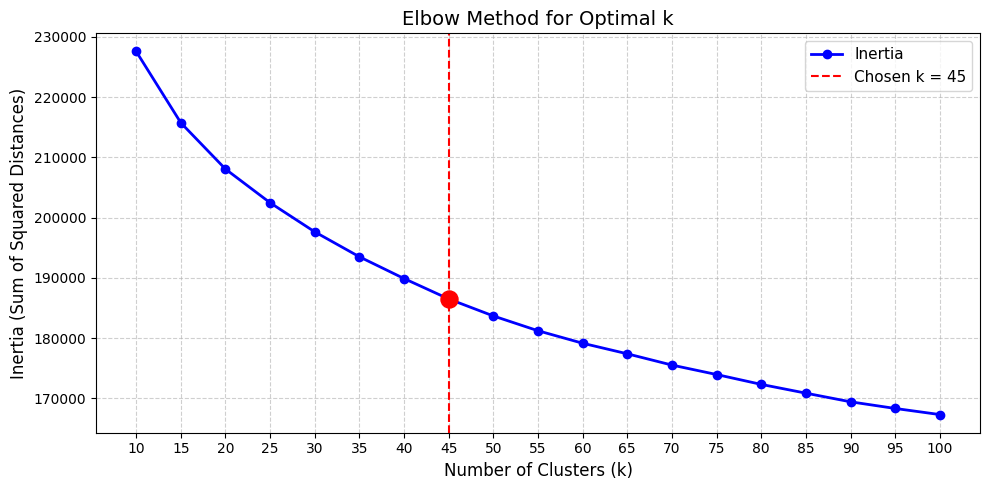

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from cuml.cluster import KMeans

# 1. Install kneed for automatic elbow point detection if not present
# !pip install kneed
from kneed import KneeLocator

# 2. Define range of candidate k values
k_range = list(range(10, 101, 5))
inertias = []

# 3. Compute GPU K-Means inertia for each k
print("Calculating inertia across k values...")
for k in k_range:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5,
        max_iter=300
    )
    kmeans_model.fit(X_reduced)
    inertias.append(float(kmeans_model.inertia_))

# 4. Automatically identify the elbow point
kn = KneeLocator(
    k_range,
    inertias,
    curve='convex',
    direction='decreasing'
)
optimal_k = kn.elbow

print(f"\nOptimal value of k identified by Elbow Method: {optimal_k}")

# 5. Plot the Elbow Graph
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=6, label='Inertia')

if optimal_k:
    optimal_inertia = inertias[k_range.index(optimal_k)]
    plt.axvline(
        x=optimal_k,
        color='r',
        linestyle='--',
        label=f'Chosen k = {optimal_k}'
    )
    plt.scatter(
        [optimal_k],
        [optimal_inertia],
        color='red',
        s=150,
        zorder=5
    )

plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 11. GPU K-MEANS
# ============================================================

N_CLUSTERS = 45


print(
    f"\nRunning GPU K-Means "
    f"with {N_CLUSTERS} clusters..."
)

kmeans_start = time.time()

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300,
    verbose=1
)

labels_gpu = kmeans.fit_predict(
    X_reduced
)

kmeans_time = time.time() - kmeans_start

print(
    f"\nK-Means completed in "
    f"{kmeans_time / 60:.2f} minutes"
)





Running GPU K-Means with 45 clusters...

K-Means completed in 0.07 minutes


In [28]:
# ============================================================
# 12. MOVE CLUSTER LABELS TO CPU
# ============================================================

labels = cp.asnumpy(
    labels_gpu
)

df["cluster"] = labels




In [29]:
# ============================================================
# 13. CLUSTER SIZE
# ============================================================

print("\nCluster sizes:")

cluster_sizes = (
    df["cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)





Cluster sizes:
cluster
0      3447
1      5117
2      6963
3      6518
4      6335
5      7794
6      5536
7     10302
8      3923
9      4861
10    10124
11     6727
12     6238
13     9455
14     5463
15     9748
16     6927
17     7038
18     8135
19     6004
20     6219
21     4257
22     7090
23     7809
24     6584
25     4043
26     5261
27     6006
28     6132
29     6551
30     5165
31     5180
32     7851
33     8852
34     7057
35     7446
36     3838
37     6730
38     5227
39     3277
40     7046
41     5181
42     6373
43     5174
44     6417
Name: count, dtype: int64


In [31]:
# Save as Parquet to natively preserve vector arrays and compress disk space
output_path = "/content/papers_clustered.parquet"
df.to_parquet(output_path, index=False)

In [32]:
# ============================================================
# 15. REPRESENTATIVE PAPER FOR EACH CLUSTER (WITH EMBEDDINGS)
# ============================================================
print("\nFinding representative papers...")

centers = kmeans.cluster_centers_
representative_papers = []

for cluster_id in range(N_CLUSTERS):
    indices = np.where(labels == cluster_id)[0]
    if len(indices) == 0:
        continue

    cluster_vectors = X_reduced[indices]

    # Cosine similarity because vectors are L2 normalized
    similarities = cluster_vectors @ centers[cluster_id]
    best_position = int(cp.argmax(similarities))
    best_index = indices[best_position]

    representative_papers.append({
        "cluster": cluster_id,
        "cluster_size": len(indices),
        "id": df.iloc[best_index]["id"],
        "title": df.iloc[best_index]["title"],
        "category": df.iloc[best_index]["category"],
        "summary": df.iloc[best_index]["summary"],
        "similarity_to_center": float(similarities[best_position]),
        # --- ADDED EMBEDDINGS HERE ---
        "embedding": df.iloc[best_index]["embedding"].tolist() if hasattr(df.iloc[best_index]["embedding"], "tolist") else df.iloc[best_index]["embedding"],
        "pca_vector": X_reduced[best_index].get().tolist()
    })

representative_df = pd.DataFrame(representative_papers)


Finding representative papers...


In [33]:
# ============================================================
# 16. SAVE REPRESENTATIVE PAPERS (PARQUET FORMAT)
# ============================================================
representative_df.to_parquet("/content/representative_papers.parquet", index=False)
print("Saved representative papers with embeddings to parquet.")

Saved representative papers with embeddings to parquet.


In [34]:
# ============================================================
# 17. DISPLAY REPRESENTATIVE PAPERS
# ============================================================

pd.set_option(
    "display.max_colwidth",
    150
)

print("\nRepresentative papers:\n")

print(
    representative_df[
        [
            "cluster",
            "cluster_size",
            "category",
            "title",
            "similarity_to_center"
        ]
    ].to_string(index=False)
)





Representative papers:

 cluster  cluster_size                                               category                                                                                                                              title  similarity_to_center
       0          3447                                       Machine Learning                                                     A hierarchy tree data structure for behavior-based user segment representation              0.522586
       1          5117                                               Robotics                                                   Tether: Autonomous Functional Play with Correspondence-Driven Trajectory Warping              0.567310
       2          6963                Computer Vision and Pattern Recognition                                                                           Identification via Retinal Vessels Combining LBP and HOG              0.425078
       3          6518             Computation and 

In [35]:
# ============================================================
# 18. TOTAL TIME
# ============================================================

total_time = (
    time.time() - start_time
)

print("\n======================================")
print("CLUSTERING COMPLETE")
print("======================================")

print(
    f"Total time: "
    f"{total_time / 60:.2f} minutes"
)

print(
    f"PCA time: "
    f"{pca_time / 60:.2f} minutes"
)

print(
    f"K-Means time: "
    f"{kmeans_time / 60:.2f} minutes"
)


CLUSTERING COMPLETE
Total time: 31.40 minutes
PCA time: 0.01 minutes
K-Means time: 0.07 minutes


## Reading saved `papers_clustered.parquet` file

In [38]:
import pandas as pd

# 1. Load a small sample (first 5 rows)
df_sample = pd.read_parquet("/content/papers_clustered.parquet")
df_sample.head()

# 2. Display the DataFrame structure
print("--- DataFrame Columns & Shape ---")
print(f"Columns: {df_sample.columns.tolist()}")

# 3. Check embedding vector properties
sample_embedding = df_sample["embedding"].iloc[0]
print(f"\nEmbedding Type: {type(sample_embedding)}")
print(f"Embedding Length: {len(sample_embedding)}")

# 4. View table content (truncating embedding column visually for clean display)
display(df_sample.assign(embedding="[768-dim float vector]"))

--- DataFrame Columns & Shape ---
Columns: ['id', 'title', 'category', 'summary', 'embedding', 'cluster']

Embedding Type: <class 'numpy.ndarray'>
Embedding Length: 768


,id,title,category,summary,embedding,cluster
0,cs-9308101v1,Dynamic Backtracking,Artificial Intelligence,"Because of their occasional need to return to shallow points in a search\ntree, existing backtracking methods can sometimes erase meaningful progr...",[768-dim float vector],16
1,cs-9308102v1,A Market-Oriented Programming Environment and its Application to\n Distributed Multicommodity Flow Problems,Artificial Intelligence,Market price systems constitute a well-understood class of mechanisms that\nunder certain conditions provide effective decentralization of decisio...,[768-dim float vector],12
2,cs-9309101v1,An Empirical Analysis of Search in GSAT,Artificial Intelligence,"We describe an extensive study of search in GSAT, an approximation procedure\nfor propositional satisfiability. GSAT performs greedy hill-climbing...",[768-dim float vector],12
3,cs-9311101v1,The Difficulties of Learning Logic Programs with Cut,Artificial Intelligence,"As real logic programmers normally use cut (!), an effective learning\nprocedure for logic programs should be able to deal with it. Because the cu...",[768-dim float vector],12
4,cs-9311102v1,Software Agents: Completing Patterns and Constructing User Interfaces,Artificial Intelligence,"To support the goal of allowing users to record and retrieve information,\nthis paper describes an interactive note-taking system for pen-based co...",[768-dim float vector],28
...,...,...,...,...,...,...
287416,abs-2606.02874v1,Neural Posterior Estimation for Stochastic Epidemic Models Using Final Outcome Data,Computation (Statistics),Neural posterior estimation (NPE) is a simulation-based approach to Bayesian inference that trains a neural network to approximate the posterior d...,[768-dim float vector],4
287417,abs-2606.02795v1,Recovering Direct Price Effects of Environmental Amenities in Housing Markets: Regression and Causal Machine Learning Model Assessment with Empiri...,Econometrics,"Hedonic price models are widely used to assess how environmental amenities affect property values, yet methodological guidance for estimating dire...",[768-dim float vector],26
287418,abs-2606.02081v1,Decision-calibrated prediction sets for robust power system operations,Optimization and Control,Robust optimization offers a tractable approach to balance operating costs and reliability in power systems dominated by weather-dependent renewab...,[768-dim float vector],41
287419,abs-2606.02017v1,PliableBVS: A flexible Bayesian variable selection method for modeling interactions with mandatory modifying variables,Methodology (Statistics),"High-dimensional interaction models are useful for studying, for example, how a large set of variables of interest, such as gene expression or oth...",[768-dim float vector],26


In [45]:
df_sample["embedding"][0]

array([ 1.69538874e-02,  6.02730736e-02, -3.30882296e-02,  2.73308214e-02,
       -5.88547885e-02, -5.40435575e-02, -8.37215558e-02,  2.41698809e-02,
        1.72638509e-03,  8.50150071e-04,  9.22443196e-02,  2.74796747e-02,
        3.97440832e-04,  9.64804436e-04, -3.17812003e-02, -7.44353095e-03,
       -9.30230226e-03,  1.73270497e-02, -2.33283602e-02,  3.50303657e-04,
       -4.62691151e-02, -3.79558429e-02, -1.57175809e-02, -3.55582573e-02,
       -8.70496407e-02, -2.73004230e-02, -7.24706873e-02,  2.63235644e-02,
        4.26542386e-02, -1.39397839e-02, -5.48198773e-03, -1.60567928e-03,
       -5.20111993e-02,  5.20610511e-02,  2.37053109e-06,  3.14727724e-02,
       -5.02393059e-02, -2.69350819e-02, -2.07182653e-02,  5.97624406e-02,
       -5.17041050e-02,  7.94927031e-02,  1.64907537e-02,  1.06422252e-04,
       -4.16752249e-02,  2.81246286e-03,  2.87434664e-02,  7.07552116e-03,
        1.47410184e-02,  1.60564226e-03, -6.98299287e-03,  2.53166594e-02,
        1.78327039e-02,  

In [43]:
len(df_sample['category'].unique())

146

In [42]:
len(df_sample['cluster'].unique())

45

## number of data points ( in our case, number of research papers) in each cluster

In [48]:
df_sample.groupby("cluster").size()

,0
cluster,
0,3447
1,5117
2,6963
3,6518
4,6335
5,7794
6,5536
7,10302
8,3923


In [49]:
cluster_0_papers = df_sample[df_sample["cluster"] == 0]
display(cluster_0_papers[["id", "category", "title"]])

,id,category,title
455,abs-0811.1319v2,Artificial Intelligence,Modeling Social Annotation: a Bayesian Approach
538,abs-0909.2376v1,Artificial Intelligence,Performing Hybrid Recommendation in Intermodal Transportation-the\n FTMarket System's Recommendation Module
556,abs-1011.2304v1,Artificial Intelligence,Target tracking in the recommender space: Toward a new recommender\n system based on Kalman filtering
578,abs-1012.3280v1,Artificial Intelligence,A new Recommender system based on target tracking: a Kalman Filter\n approach
591,abs-1101.2378v1,Artificial Intelligence,Extracting Features from Ratings: The Role of Factor Models
...,...,...,...
286367,abs-2505.04434v1,Information Retrieval,Theoretical Guarantees for LT-TTD: A Unified Transformer-based Architecture for Two-Level Ranking Systems
286833,abs-2512.21111v1,Statistics Theory,Statistical and computational challenges in ranking
286892,abs-2512.03807v2,Information Retrieval,Algorithms for Boolean Matrix Factorization using Integer Programming and Heuristics
287093,abs-2603.21699v1,Econometrics,A Job I Like or a Job I Can Get: Designing Job Recommender Systems Using Field Experiments


## Saving the result files in google drive

In [ ]:
import shutil

print("Copying Parquet files to Google Drive...")

# Copy Parquet datasets
shutil.copy('/content/papers_clustered.parquet', '/content/drive/MyDrive/papers_clustered.parquet')
shutil.copy('/content/representative_papers.parquet', '/content/drive/MyDrive/representative_papers.parquet')

print("Files successfully copied to Google Drive!")

## end-to-end pipeline in a single cell

In [ ]:
# # ============================================================
# # 2. IMPORTS
# # ============================================================
# import gc
# import time
# import numpy as np
# import pandas as pd
# import cupy as cp
# from cuml.preprocessing import normalize
# from cuml.decomposition import PCA
# from cuml.cluster import KMeans
# from google.colab import drive

# drive.mount('/content/drive')

# # ============================================================
# # CONFIGURATION
# # ============================================================
# DATA_PATH = "/content/drive/MyDrive/arxiv_with_embeddings.parquet"
# PCA_COMPONENTS = 100
# N_CLUSTERS = 45
# RANDOM_STATE = 42

# # ============================================================
# # 3. LOAD DATA & CONVERT MATRIX
# # ============================================================
# start_time = time.time()
# print("Loading dataset...")
# df = pd.read_parquet(DATA_PATH)
# print("Dataset shape:", df.shape)

# print("\nCreating embedding matrix...")
# # Stack arrays directly into a 2D float32 numpy matrix
# X = np.vstack(df["embedding"].values).astype(np.float32)

# if X.shape[1] != 768:
#     raise ValueError(f"Expected 768 dimensions, got {X.shape[1]}")

# # ============================================================
# # 4. MOVE TO GPU & NORMALIZE
# # ============================================================
# print("Moving embeddings to GPU...")
# X_gpu = cp.asarray(X)
# del X
# gc.collect()
# cp.get_default_memory_pool().free_all_blocks()

# print("L2 normalizing embeddings...")
# X_gpu = normalize(X_gpu, axis=1, norm="l2")

# # ============================================================
# # 5. PCA REDUCTION (Fixed: removed random_state)
# # ============================================================
# print(f"\nRunning GPU PCA (768 -> {PCA_COMPONENTS})...")
# pca_start = time.time()
# pca = PCA(n_components=PCA_COMPONENTS)
# X_reduced = pca.fit_transform(X_gpu)

# print(f"PCA completed in {(time.time() - pca_start) / 60:.2f} minutes")
# print(f"Explained variance: {float(cp.sum(pca.explained_variance_ratio_)):.4f}")

# # Free original embeddings from GPU memory
# del X_gpu
# gc.collect()
# cp.get_default_memory_pool().free_all_blocks()

# # Normalize PCA embeddings
# X_reduced = normalize(X_reduced, axis=1, norm="l2")

# # ============================================================
# # 6. GPU K-MEANS CLUSTERING
# # ============================================================
# print(f"\nRunning GPU K-Means ({N_CLUSTERS} clusters)...")
# kmeans_start = time.time()
# kmeans = KMeans(
#     n_clusters=N_CLUSTERS,
#     random_state=RANDOM_STATE,
#     n_init=10,
#     max_iter=300,
#     verbose=1
# )
# labels_gpu = kmeans.fit_predict(X_reduced)
# kmeans_time = time.time() - kmeans_start

# print(f"\nK-Means completed in {kmeans_time / 60:.2f} minutes")

# # Save labels back to DataFrame
# df["cluster"] = cp.asnumpy(labels_gpu)

# # ============================================================
# # 7. FIND REPRESENTATIVE PAPERS & SAVE RESULTS
# # ============================================================
# print("\nFinding representative papers...")
# centers = kmeans.cluster_centers_
# labels = df["cluster"].values
# representative_papers = []

# for cluster_id in range(N_CLUSTERS):
#     indices = np.where(labels == cluster_id)[0]
#     if len(indices) == 0:
#         continue

#     cluster_vectors = X_reduced[indices]
#     similarities = cp.dot(cluster_vectors, centers[cluster_id])
#     best_position = int(cp.argmax(similarities))
#     best_index = indices[best_position]

#     representative_papers.append({
#         "cluster": cluster_id,
#         "cluster_size": len(indices),
#         "id": df.iloc[best_index]["id"],
#         "title": df.iloc[best_index]["title"],
#         "category": df.iloc[best_index]["category"],
#         "summary": df.iloc[best_index]["summary"],
#         "similarity_to_center": float(similarities[best_position])
#     })

# representative_df = pd.DataFrame(representative_papers)

# # Save Outputs
# df.to_csv("/content/papers_clustered.csv", index=False)
# representative_df.to_csv("/content/representative_papers.csv", index=False)

# print(f"\nCLUSTERING COMPLETE in {(time.time() - start_time) / 60:.2f} minutes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Dataset shape: (287421, 5)

Creating embedding matrix...
Moving embeddings to GPU...
L2 normalizing embeddings...

Running GPU PCA (768 -> 100)...
PCA completed in 0.01 minutes
Explained variance: 0.7399

Running GPU K-Means (50 clusters)...

K-Means completed in 0.06 minutes

Finding representative papers...

CLUSTERING COMPLETE in 25.94 minutes
